In [14]:
import sys, os
sys.path.append(os.path.abspath('..'))

from src.preprocess import load_and_preprocess
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import numpy as np
from sklearn.metrics import accuracy_score

In [15]:
X_train, X_test, y_train, y_test = load_and_preprocess('../data/diabetes.csv')

In [16]:
# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_probs = nb_model.predict_proba(X_test)[:,1]

# ANN (MLP)
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
ann_probs = mlp.predict_proba(X_test)[:,1]

/workspaces/medical-diagnosis-hybrid-ml/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [17]:
alpha = 0.4   # weight for Naive Bayes
beta = 0.6    # weight for ANN

combined_probs = alpha * nb_probs + beta * ann_probs

In [18]:
final_pred = (combined_probs >= 0.5).astype(int)

In [19]:
print("Hybrid Accuracy:", accuracy_score(y_test, final_pred))

Hybrid Accuracy: 0.7532467532467533


In [20]:
nb_pred = (nb_probs >= 0.5).astype(int)
ann_pred = (ann_probs >= 0.5).astype(int)

print("NB Accuracy:", accuracy_score(y_test, nb_pred))
print("ANN Accuracy:", accuracy_score(y_test, ann_pred))
print("Hybrid Accuracy:", accuracy_score(y_test, final_pred))

NB Accuracy: 0.7662337662337663
ANN Accuracy: 0.7142857142857143
Hybrid Accuracy: 0.7532467532467533


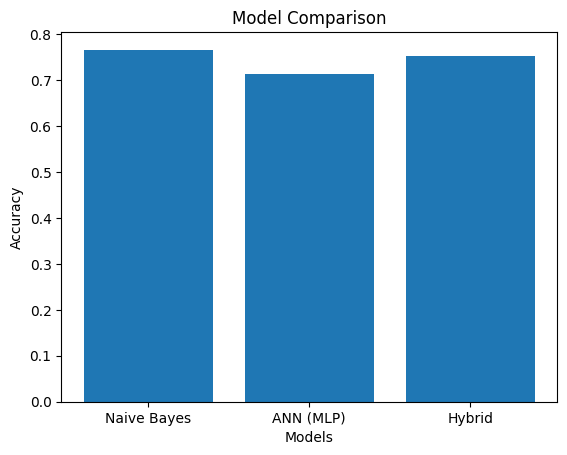

In [21]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'ANN (MLP)', 'Hybrid']
accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, ann_pred),
    accuracy_score(y_test, final_pred)
]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()


In [23]:
plt.savefig('../results/model_comparison.png')

<Figure size 640x480 with 0 Axes>

In [24]:
import joblib

joblib.dump(nb_model, '../models/nb_model.pkl')
joblib.dump(mlp, '../models/ann_model.pkl')

['../models/ann_model.pkl']

In [25]:
from src.preprocess import load_and_preprocess
load_and_preprocess('../data/diabetes.csv')

(array([[-0.54791859, -1.15469351, -3.57259724, ..., -4.06047387,
         -0.50700636, -1.04154944],
        [ 1.53084665, -0.27837344,  0.66661825, ..., -0.48135115,
          2.44666971,  1.4259954 ],
        [-0.84488505,  0.56664949, -1.19450074, ..., -0.41789153,
          0.55003518, -0.95646168],
        ...,
        [ 1.82781311, -0.62264204,  0.87340925, ...,  1.72704372,
          2.00573238,  0.40494237],
        [-1.14185152,  0.62924378, -3.57259724, ...,  1.32090213,
         -0.8059981 , -0.36084741],
        [-1.14185152,  0.12848945,  1.39038675, ..., -1.20479085,
         -0.63385134, -1.04154944]], shape=(614, 8)),
 array([[ 0.63994726, -0.71653347, -0.57412775, ...,  0.25478047,
         -0.1264714 ,  0.83038113],
        [-0.54791859, -0.27837344,  0.304734  , ...,  0.47054319,
         -0.97814487, -1.04154944],
        [-0.54791859, -0.40356202, -0.26394125, ..., -0.15136112,
         -0.94794368, -1.04154944],
        ...,
        [ 1.23388019, -0.81042491,  0.

In [26]:
import joblib
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv('../data/diabetes.csv')

X = df.drop('Outcome', axis=1)

scaler = StandardScaler()
scaler.fit(X)

joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']